# 📋 claude.ai 프롬프트 / claude.ai Prompt

> **수업 활용법:** 아래 프롬프트를 [claude.ai](https://claude.ai)에 붙여넣으면 유사한 실습 노트북을 직접 생성할 수 있습니다.

---

### 🇰🇷 한국어 프롬프트
```
RAG(검색 증강 생성)의 핵심 기술인 텍스트 임베딩과 벡터 검색을
초보자도 이해할 수 있는 Google Colab 노트북으로 한국어로 작성해주세요.
다음을 포함하세요:
1. pip로 sentence-transformers, scikit-learn, matplotlib 설치
2. 임베딩이란 무엇인지 지도 좌표 비유로 쉽게 설명
3. 한국어 문장 6개(주제별: 날씨, AI, 요리, 스포츠, 비즈니스, IT)의 임베딩 생성
   - 모델: paraphrase-multilingual-MiniLM-L12-v2 (다국어 지원)
4. 코사인 유사도 행렬을 matplotlib 히트맵으로 시각화
5. 질문을 입력하면 가장 유사한 문장 3개를 반환하는 검색 함수 구현
6. 미니 실습: 본인만의 문장 3개 추가하고 검색해보기
각 단계에 한국어 설명과 코드 주석 포함. 시각적이고 직관적으로 작성.
```

### 🇺🇸 English Prompt
```
Create a Korean-language Google Colab notebook on text embeddings and vector search
as the core technology behind RAG, for beginners. Include:
1. Install sentence-transformers, scikit-learn, matplotlib
2. Explain embeddings with a map coordinates analogy
3. Generate embeddings for 6 Korean sentences (different topics)
   - Model: paraphrase-multilingual-MiniLM-L12-v2
4. Visualize cosine similarity matrix as a heatmap
5. Implement semantic search: return top-3 most similar sentences for a query
6. Mini exercise: add 3 custom sentences and search them
Include Korean explanations and comments. Keep it visual and intuitive.
```

# FM1 실습 2: 임베딩과 벡터 검색

## 학습 목표
- 텍스트 임베딩의 개념을 직관적으로 이해한다
- 코사인 유사도로 텍스트 간의 유사성을 측정한다
- 의미 기반 검색(Semantic Search)을 직접 구현한다
- 이 기술이 RAG의 핵심임을 이해한다

In [1]:
# 필요한 라이브러리 설치
!pip install sentence-transformers scikit-learn matplotlib -q
print("✅ 설치 완료!")

✅ 설치 완료!


## 🗺️ 임베딩이란 무엇인가?

임베딩은 **텍스트를 숫자 벡터(좌표)로 변환**하는 것입니다.

**지도 비유:** 서울, 부산, 인천이 지도에서 각각 특정 좌표(위도, 경도)를 갖듯이,  
"강아지"와 "개"는 의미가 비슷하므로 벡터 공간에서 **가까운 좌표**를 가집니다.  
"강아지"와 "자동차"는 의미가 다르므로 **먼 좌표**를 가집니다.

이 성질을 이용하면 **"의미가 비슷한 문장"을 빠르게 검색**할 수 있습니다. → RAG의 핵심!

In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np

# 다국어 임베딩 모델 로드 (한국어 지원)
# 처음 실행 시 모델을 다운로드하므로 잠시 기다리세요 (~1분)
print("모델 로딩 중...")
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("✅ 모델 로딩 완료!")

모델 로딩 중...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 모델 로딩 완료!


In [3]:
# 주제가 다른 한국어 문장 6개 준비
sentences = [
    "오늘 날씨가 맑고 기온이 25도입니다.",          # 날씨
    "내일 비가 올 것 같아 우산을 챙겼습니다.",       # 날씨
    "인공지능이 의료 진단에 혁신을 가져오고 있습니다.",  # AI
    "ChatGPT는 자연어처리 기술을 대중화했습니다.",    # AI
    "파스타를 만들려면 올리브 오일과 마늘이 필요합니다.",  # 요리
    "분기별 매출이 전년 대비 15% 증가했습니다.",     # 비즈니스
]

labels = ["날씨1", "날씨2", "AI1", "AI2", "요리", "비즈니스"]

# 임베딩 생성
embeddings = model.encode(sentences)

print(f"임베딩 행렬 크기: {embeddings.shape}")
print(f"→ {len(sentences)}개 문장, 각각 {embeddings.shape[1]}차원 벡터")

임베딩 행렬 크기: (6, 384)
→ 6개 문장, 각각 384차원 벡터


Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


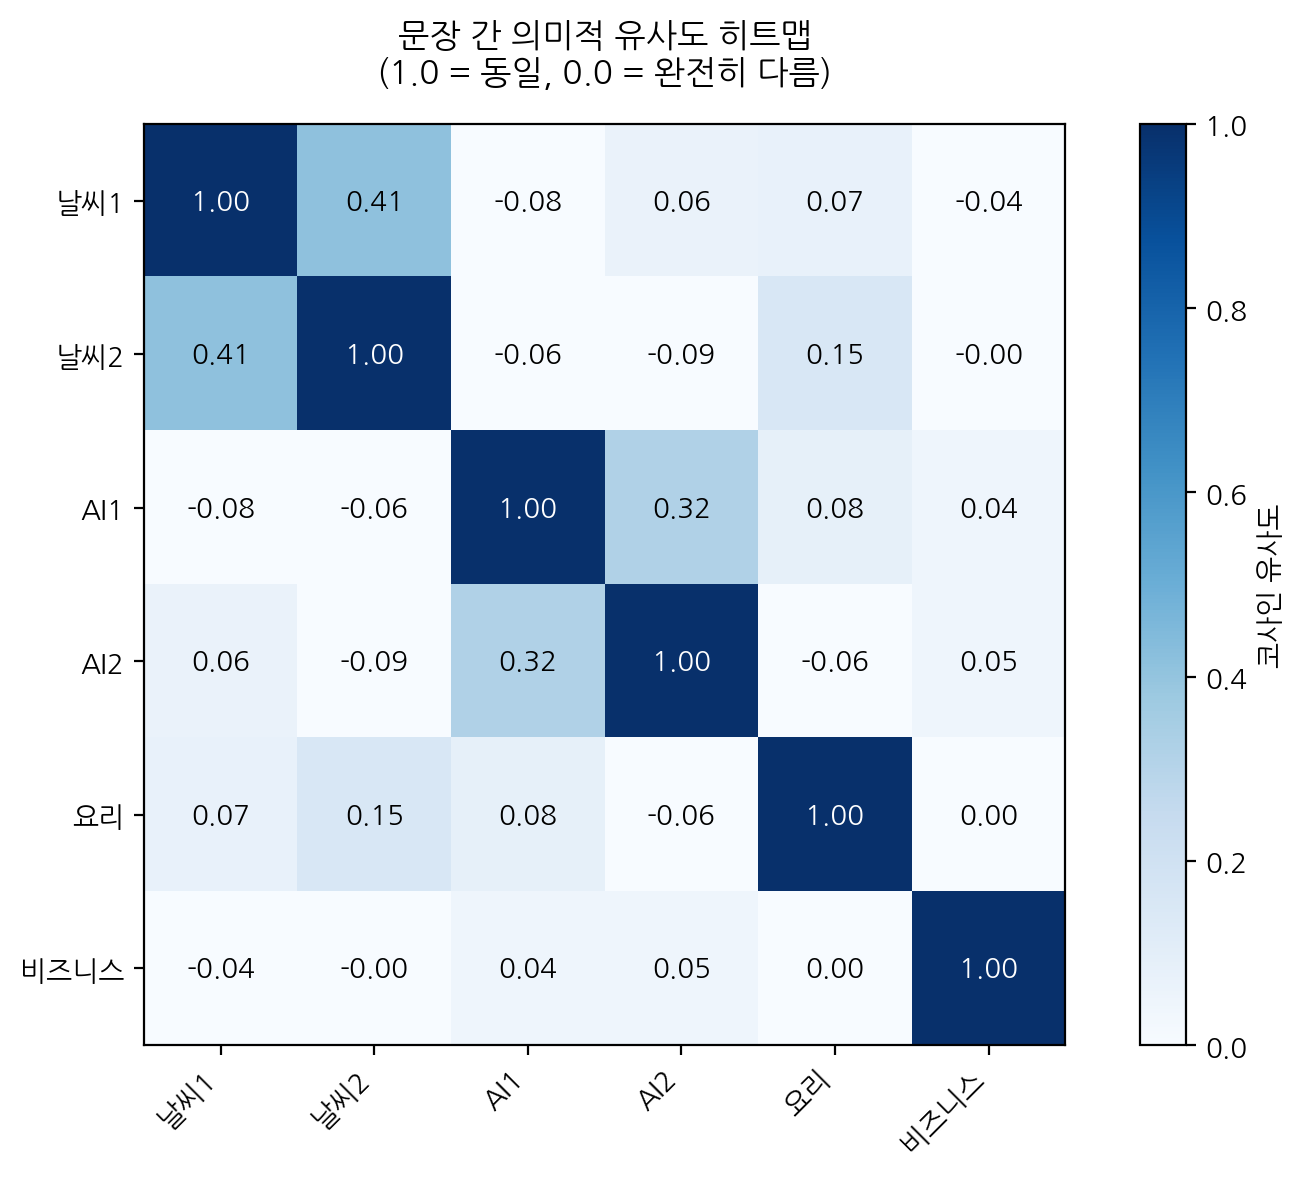


💡 같은 주제의 문장끼리(날씨1-날씨2, AI1-AI2) 유사도가 높은 것을 확인하세요!


In [7]:
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics.pairwise import cosine_similarity

# 한글 폰트 설치
!apt-get install -y fonts-nanum -q 2>/dev/null

import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

%config InlineBackend.figure_format = 'retina'

# 코사인 유사도 행렬 계산
# 값이 1에 가까울수록 의미가 비슷, 0에 가까울수록 다름
similarity_matrix = cosine_similarity(embeddings)

# 히트맵 시각화
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(similarity_matrix, cmap='Blues', vmin=0, vmax=1)

# 축 레이블 설정
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

# 각 셀에 값 표시
for i in range(len(sentences)):
    for j in range(len(sentences)):
        ax.text(j, i, f"{similarity_matrix[i,j]:.2f}",
                ha='center', va='center',
                color='white' if similarity_matrix[i,j] > 0.7 else 'black',
                fontsize=10)

plt.colorbar(im, ax=ax, label='코사인 유사도')
ax.set_title('문장 간 의미적 유사도 히트맵\n(1.0 = 동일, 0.0 = 완전히 다름)', pad=15)
plt.tight_layout()
plt.show()

print("\n💡 같은 주제의 문장끼리(날씨1-날씨2, AI1-AI2) 유사도가 높은 것을 확인하세요!")

## 🔍 의미 기반 검색 (Semantic Search) 구현

In [8]:
def semantic_search(query, sentences, embeddings, model, top_k=3):
    """
    의미 기반 검색 함수
    query: 검색 질문
    sentences: 검색할 문장 목록
    embeddings: 미리 계산된 문장 임베딩
    top_k: 반환할 상위 결과 수
    """
    # 질문도 임베딩으로 변환
    query_embedding = model.encode([query])

    # 질문과 각 문장 간의 코사인 유사도 계산
    similarities = cosine_similarity(query_embedding, embeddings)[0]

    # 유사도 높은 순으로 정렬
    top_indices = similarities.argsort()[::-1][:top_k]

    print(f"🔍 검색어: '{query}'")
    print("-" * 50)
    for rank, idx in enumerate(top_indices, 1):
        print(f"  {rank}위 (유사도: {similarities[idx]:.3f}): {sentences[idx]}")
    print()

# 테스트: 다양한 질문으로 검색해보기
semantic_search("비가 올 것 같아요", sentences, embeddings, model)
semantic_search("머신러닝 기술 발전", sentences, embeddings, model)
semantic_search("회사 실적 보고", sentences, embeddings, model)

🔍 검색어: '비가 올 것 같아요'
--------------------------------------------------
  1위 (유사도: 0.553): 내일 비가 올 것 같아 우산을 챙겼습니다.
  2위 (유사도: 0.273): 오늘 날씨가 맑고 기온이 25도입니다.
  3위 (유사도: 0.083): ChatGPT는 자연어처리 기술을 대중화했습니다.

🔍 검색어: '머신러닝 기술 발전'
--------------------------------------------------
  1위 (유사도: 0.544): 인공지능이 의료 진단에 혁신을 가져오고 있습니다.
  2위 (유사도: 0.369): ChatGPT는 자연어처리 기술을 대중화했습니다.
  3위 (유사도: 0.086): 파스타를 만들려면 올리브 오일과 마늘이 필요합니다.

🔍 검색어: '회사 실적 보고'
--------------------------------------------------
  1위 (유사도: 0.210): 내일 비가 올 것 같아 우산을 챙겼습니다.
  2위 (유사도: 0.155): 오늘 날씨가 맑고 기온이 25도입니다.
  3위 (유사도: 0.154): ChatGPT는 자연어처리 기술을 대중화했습니다.



## ✏️ 미니 실습: 나만의 문장 추가하기

아래 `my_sentences`에 본인과 관련된 문장 3개를 추가하고 검색해보세요!

In [9]:
# ✏️ 여기에 본인만의 문장을 추가하세요!
my_sentences = [
    "여기에 첫 번째 문장을 입력하세요.",   # 예: 업무 관련 문장
    "두 번째 문장을 입력하세요.",
    "세 번째 문장을 입력하세요.",
]

# 기존 문장과 합치기
all_sentences = sentences + my_sentences
all_embeddings = model.encode(all_sentences)

# 검색어도 바꿔보세요!
my_query = "여기에 검색하고 싶은 질문을 입력하세요"
semantic_search(my_query, all_sentences, all_embeddings, model)

🔍 검색어: '여기에 검색하고 싶은 질문을 입력하세요'
--------------------------------------------------
  1위 (유사도: 0.509): 여기에 첫 번째 문장을 입력하세요.
  2위 (유사도: 0.469): 두 번째 문장을 입력하세요.
  3위 (유사도: 0.462): 세 번째 문장을 입력하세요.



## 📝 정리

| 개념 | 설명 |
|------|------|
| 임베딩 | 텍스트를 숫자 벡터로 변환 (의미가 비슷 = 벡터가 가깝다) |
| 코사인 유사도 | 두 벡터가 얼마나 비슷한 방향인지 (1=동일, 0=무관) |
| 의미 기반 검색 | 키워드 매칭이 아닌 의미로 검색 |
| RAG 연결 | 질문 임베딩 → 문서 검색 → LLM에 전달 → 답변 생성 |

**다음 실습:** 이 기술을 Claude API와 결합하여 완전한 RAG 파이프라인 구현!